# Imports and definitions

In [1]:
# imports
from matplotlib.ticker import ScalarFormatter
from scipy.integrate import simpson
from kuibit.simdir import SimDir
import matplotlib.pyplot as plt
from tabulate import tabulate
import matplotlib.cm as cm
from numpy import sqrt
import numpy as np
import os

In [2]:
# display dynamical plots
%matplotlib widget

In [3]:
# calls Carpet2ygraphCat.pl to write a 1D quantity from ASCII to plain text, with the format
# ```
#  # time = xxx
#  coord value
#  (...)
# ```
# returns a dictionary with the list of `coord` and `value` for all instants of time
# if there are more than one `output-XXXX`, it appends to the previous timesteps
# if there are overlapping time steps, then the higher output is considered
def GetMesh(sd, quantity, axis):
    coords = {}
    data = {}

    for N in [s.replace("output-", "") for s in os.popen(f"ls {sd.path}").read().split()[1:]]:
        path = f"{sd.path}/output-{N}/{quantity}.{axis}.asc"
        xgpath = f"{sd.path}/output-{N}/{quantity}.{axis}.xg"

        if not os.path.isfile(xgpath):
            os.popen(f"perl /home/undercover/projects/cactus/repos/carpet/CarpetIOASCII/src/util/Carpet2ygraphCat.pl {path}")
            os.wait()

        file = open(xgpath, "r")
        file_str = file.read()

        for block in file_str.split("\n\n#")[1:]:
            block = block.split("\n")

            time = block[0].split()[-1]

            N = len(block[1:-1])
            coords[f"t={time}"] = np.empty(N)
            data[f"t={time}"]   = np.empty(N)

            i = 0
            for line in block[1:-1]:
                line = line.split()
                coords[f"t={time}"][i] = float(line[0])
                data[f"t={time}"][i]   = float(line[1])

                i += 1

        file.close()

    return coords, data

# Head-on (dual)

In [6]:
sd           = SimDir("../simulations/Headon_M=1,0.5-T=0.1,0.05-alpha=0,0-x0=8.001_h=2.5")
ts           = sd.timeseries
gf           = sd.gf
hc_norm      = ts.norm2["hc"]
Ec_norm      = ts.norm2["Ec"]
Bc_norm      = ts.norm2["Bc"]

sd_res2      = SimDir("../simulations/Headon_M=1,0.5-T=0.1,0.05-alpha=0,0-x0=8.001_h=3")
ts_res2      = sd_res2.timeseries
gf_res2      = sd_res2.gf
hc_norm_res2 = ts_res2.norm2["hc"]
Ec_norm_res2 = ts_res2.norm2["Ec"]
Bc_norm_res2 = ts_res2.norm2["Bc"]

/tmp/ipykernel_658579/3810718464.py:46: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax[1,0].set_yscale("log")


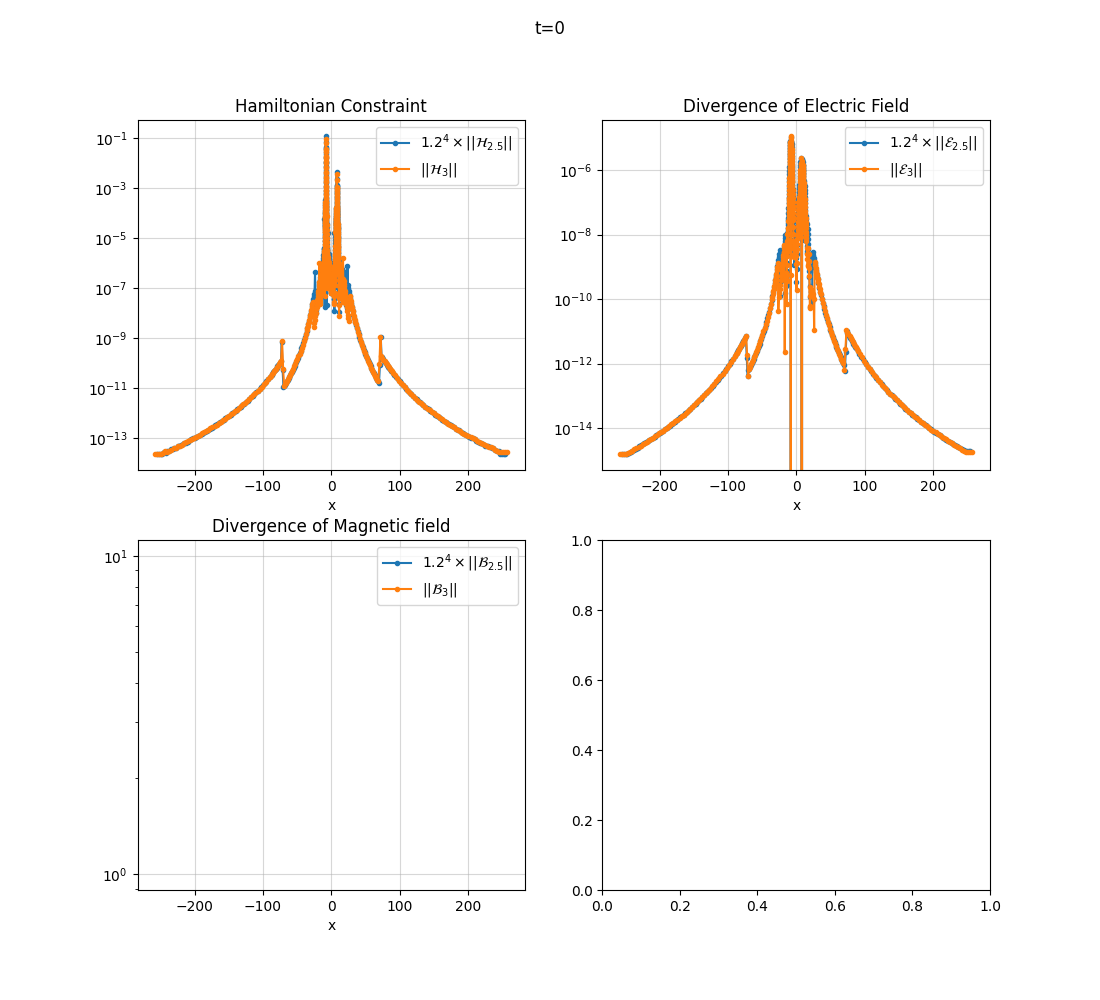

In [7]:
t    = 0  # pick time step here
axis = "x"

fig, ax = plt.subplots(2, 2, figsize=(11,10))

fig.suptitle(f"t={t}")


coor_1, data_1 = GetMesh(sd,      "hc", axis)
coor_2, data_2 = GetMesh(sd_res2, "hc", axis)

ax[0,0].plot(coor_1[f"t={t}"], 1.2**4*abs(data_1[f"t={t}"]), marker=".", label=r"$1.2^4 \times ||\mathcal{H}_{2.5}||$")
ax[0,0].plot(coor_2[f"t={t}"],        abs(data_2[f"t={t}"]), marker=".", label=r"$             ||\mathcal{H}_{3}  ||$")

ax[0,0].grid(alpha=0.5)
#ax[0,0].set_xlim(left=0)
ax[0,0].set_xlabel(axis)
ax[0,0].set_yscale("log")
ax[0,0].set_title("Hamiltonian Constraint")
ax[0,0].legend()


coor_1, data_1 = GetMesh(sd,      "Ec", axis)
coor_2, data_2 = GetMesh(sd_res2, "Ec", axis)

ax[0,1].plot(coor_1[f"t={t}"], 1.2**4*abs(data_1[f"t={t}"]), marker=".", label=r"$1.2^4 \times ||\mathcal{E}_{2.5}||$")
ax[0,1].plot(coor_2[f"t={t}"],        abs(data_2[f"t={t}"]), marker=".", label=r"$             ||\mathcal{E}_{3}  ||$")

ax[0,1].grid(alpha=0.5)
#ax[0,1].set_xlim(left=0)
ax[0,1].set_xlabel(axis)
ax[0,1].set_yscale("log")
ax[0,1].set_title("Divergence of Electric Field")
ax[0,1].legend()


coor_1, data_1 = GetMesh(sd,      "Bc", axis)
coor_2, data_2 = GetMesh(sd_res2, "Bc", axis)

ax[1,0].plot(coor_1[f"t={t}"], 1.2**4*abs(data_1[f"t={t}"]), marker=".", label=r"$1.2^4 \times ||\mathcal{B}_{2.5}||$")
ax[1,0].plot(coor_2[f"t={t}"],        abs(data_2[f"t={t}"]), marker=".", label=r"$             ||\mathcal{B}_{3}  ||$")

ax[1,0].grid(alpha=0.5)
#ax[1,0].set_xlim(left=0)
ax[1,0].set_xlabel(axis)
ax[1,0].set_yscale("log")
ax[1,0].set_title("Divergence of Magnetic field")
ax[1,0].legend();

/tmp/ipykernel_658579/471706630.py:29: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax[1,0].set_yscale("log")


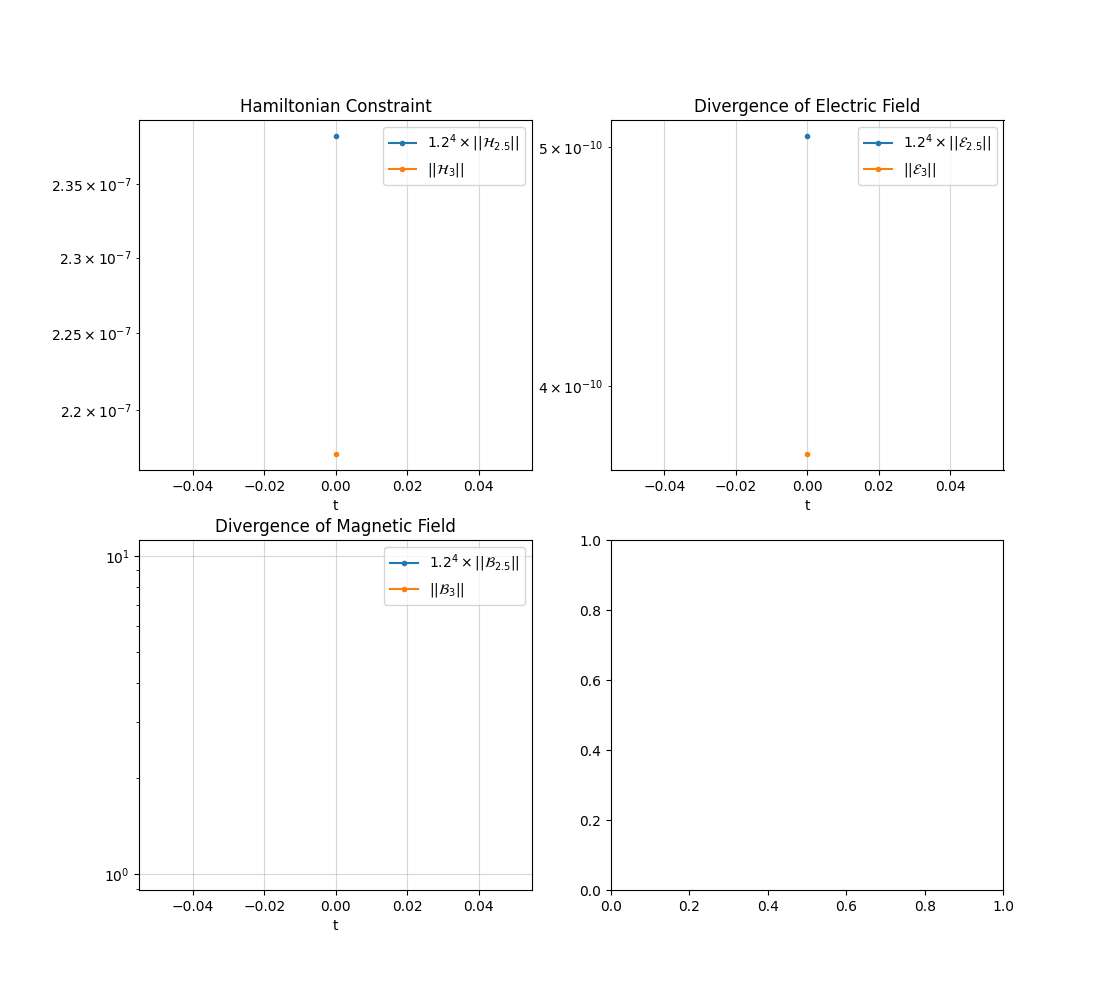

In [8]:
fig, ax = plt.subplots(2, 2, figsize=(11.15,10))


ax[0,0].plot(hc_norm.t,      1.2**4*hc_norm.y,      marker=".", label=r"$1.2^4 \times ||\mathcal{H}_{2.5}||$")
ax[0,0].plot(hc_norm_res2.t,        hc_norm_res2.y, marker=".", label=r"$             ||\mathcal{H}_{3} ||$")

ax[0,0].grid(alpha=0.5)
ax[0,0].set_xlabel("t")
ax[0,0].set_yscale("log")
ax[0,0].set_title("Hamiltonian Constraint")
ax[0,0].legend()


ax[0,1].plot(Ec_norm.t,      1.2**4*Ec_norm.y,      marker=".", label=r"$1.2^4 \times ||\mathcal{E}_{2.5}||$")
ax[0,1].plot(Ec_norm_res2.t,        Ec_norm_res2.y, marker=".", label=r"$             ||\mathcal{E}_{3}  ||$")

ax[0,1].grid(alpha=0.5)
ax[0,1].set_xlabel("t")
ax[0,1].set_yscale("log")
ax[0,1].set_title("Divergence of Electric Field")
ax[0,1].legend()


ax[1,0].plot(Bc_norm.t,      1.2**4*Bc_norm.y,      marker=".", label=r"$1.2^4 \times ||\mathcal{B}_{2.5}||$")
ax[1,0].plot(Bc_norm_res2.t,        Bc_norm_res2.y, marker=".", label=r"$             ||\mathcal{B}_{3}  ||$")

ax[1,0].grid(alpha=0.5)
ax[1,0].set_xlabel("t")
ax[1,0].set_yscale("log")
ax[1,0].set_title("Divergence of Magnetic Field")
ax[1,0].legend();

# Head-on (Q vs P)

In [9]:
sd           = SimDir("../simulations/Headon_M=1,0.5-T=0.1,0.05-alpha=0,0.5pi-x0=8.001_h=2.5")
ts           = sd.timeseries
gf           = sd.gf
hc_norm      = ts.norm2["hc"]
Ec_norm      = ts.norm2["Ec"]
Bc_norm      = ts.norm2["Bc"]

sd_res2      = SimDir("../simulations/Headon_M=1,0.5-T=0.1,0.05-alpha=0,0.5pi-x0=8.001_h=3")
ts_res2      = sd_res2.timeseries
gf_res2      = sd_res2.gf
hc_norm_res2 = ts_res2.norm2["hc"]
Ec_norm_res2 = ts_res2.norm2["Ec"]
Bc_norm_res2 = ts_res2.norm2["Bc"]

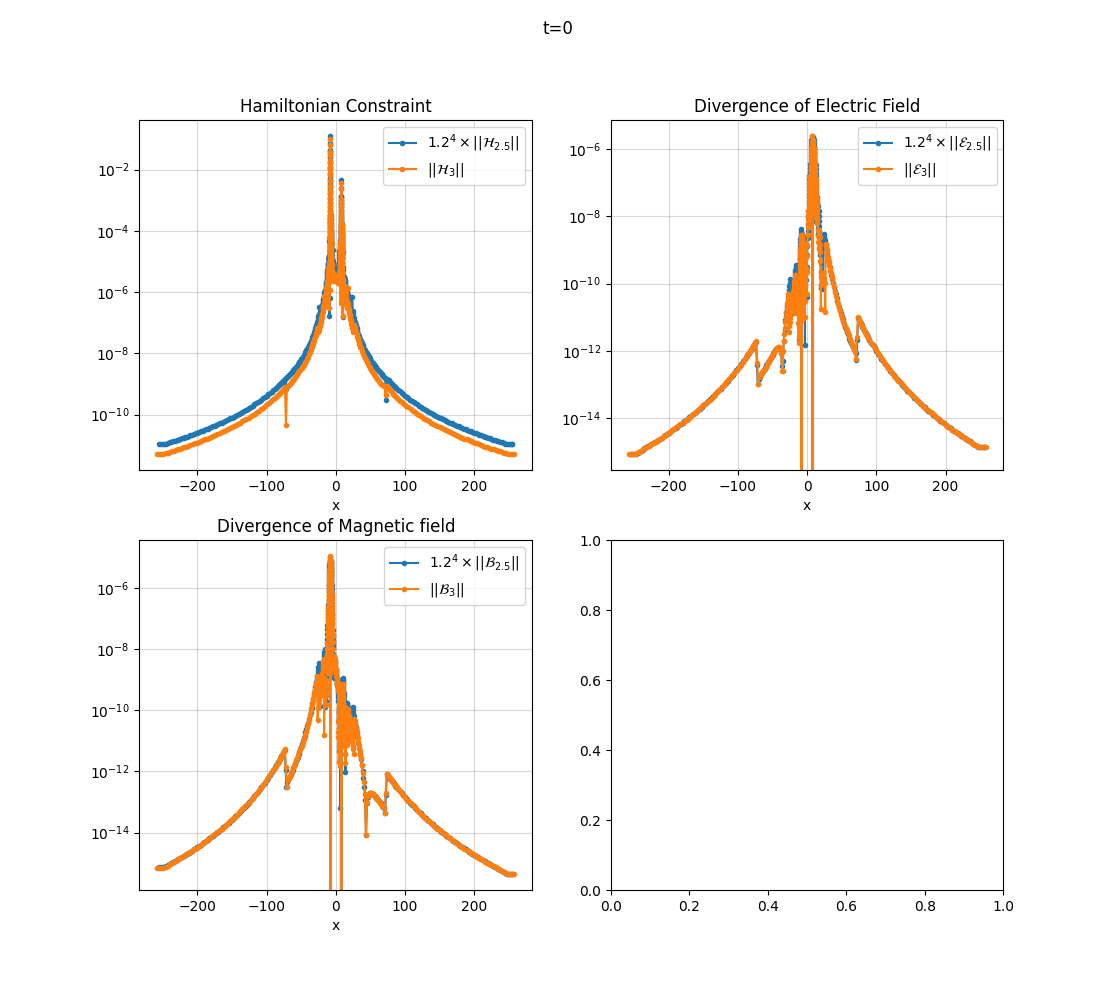

In [10]:
t    = 0  # pick time step here
axis = "x"

fig, ax = plt.subplots(2, 2, figsize=(11.15,10))

fig.suptitle(f"t={t}")


coor_1, data_1 = GetMesh(sd,      "hc", axis)
coor_2, data_2 = GetMesh(sd_res2, "hc", axis)

ax[0,0].plot(coor_1[f"t={t}"], 1.2**4*abs(data_1[f"t={t}"]), marker=".", label=r"$1.2^4 \times ||\mathcal{H}_{2.5}||$")
ax[0,0].plot(coor_2[f"t={t}"],        abs(data_2[f"t={t}"]), marker=".", label=r"$             ||\mathcal{H}_{3}  ||$")

ax[0,0].grid(alpha=0.5)
#ax[0,0].set_xlim(left=0)
ax[0,0].set_xlabel(axis)
ax[0,0].set_yscale("log")
ax[0,0].set_title("Hamiltonian Constraint")
ax[0,0].legend()


coor_1, data_1 = GetMesh(sd,      "Ec", axis)
coor_2, data_2 = GetMesh(sd_res2, "Ec", axis)

ax[0,1].plot(coor_1[f"t={t}"], 1.2**4*abs(data_1[f"t={t}"]), marker=".", label=r"$1.2^4 \times ||\mathcal{E}_{2.5}||$")
ax[0,1].plot(coor_2[f"t={t}"],        abs(data_2[f"t={t}"]), marker=".", label=r"$             ||\mathcal{E}_{3}  ||$")

ax[0,1].grid(alpha=0.5)
#ax[0,1].set_xlim(left=0)
ax[0,1].set_xlabel(axis)
ax[0,1].set_yscale("log")
ax[0,1].set_title("Divergence of Electric Field")
ax[0,1].legend()


coor_1, data_1 = GetMesh(sd,      "Bc", axis)
coor_2, data_2 = GetMesh(sd_res2, "Bc", axis)

ax[1,0].plot(coor_1[f"t={t}"], 1.2**4*abs(data_1[f"t={t}"]), marker=".", label=r"$1.2^4 \times ||\mathcal{B}_{2.5}||$")
ax[1,0].plot(coor_2[f"t={t}"],        abs(data_2[f"t={t}"]), marker=".", label=r"$             ||\mathcal{B}_{3}  ||$")

ax[1,0].grid(alpha=0.5)
#ax[1,0].set_xlim(left=0)
ax[1,0].set_xlabel(axis)
ax[1,0].set_yscale("log")
ax[1,0].set_title("Divergence of Magnetic field")
ax[1,0].legend();

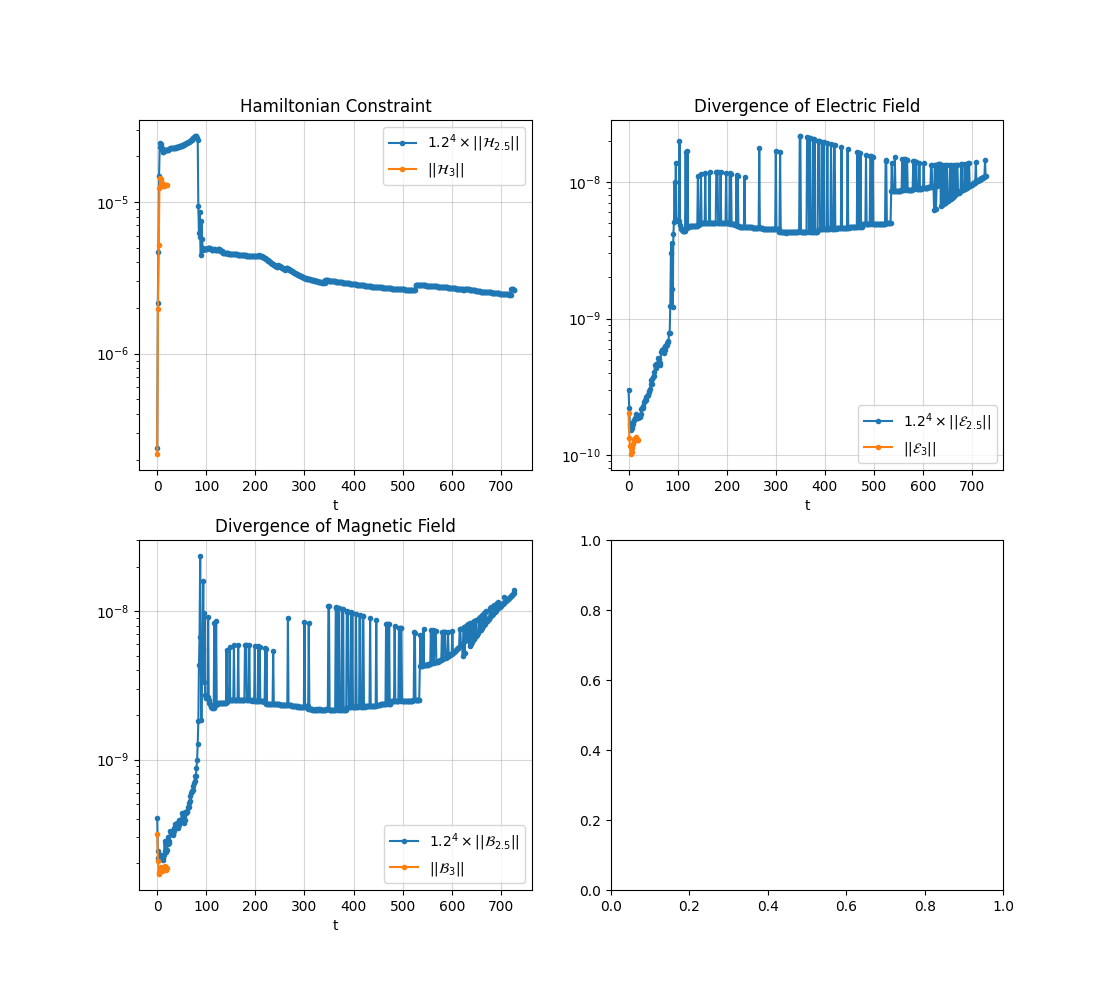

In [11]:
fig, ax = plt.subplots(2, 2, figsize=(11.15,10))


ax[0,0].plot(hc_norm.t,      1.2**4*hc_norm.y,      marker=".", label=r"$1.2^4 \times ||\mathcal{H}_{2.5}||$")
ax[0,0].plot(hc_norm_res2.t,        hc_norm_res2.y, marker=".", label=r"$             ||\mathcal{H}_{3} ||$")

ax[0,0].grid(alpha=0.5)
ax[0,0].set_xlabel("t")
ax[0,0].set_yscale("log")
ax[0,0].set_title("Hamiltonian Constraint")
ax[0,0].legend()


ax[0,1].plot(Ec_norm.t,      1.2**4*Ec_norm.y,      marker=".", label=r"$1.2^4 \times ||\mathcal{E}_{2.5}||$")
ax[0,1].plot(Ec_norm_res2.t,        Ec_norm_res2.y, marker=".", label=r"$             ||\mathcal{E}_{3}  ||$")

ax[0,1].grid(alpha=0.5)
ax[0,1].set_xlabel("t")
ax[0,1].set_yscale("log")
ax[0,1].set_title("Divergence of Electric Field")
ax[0,1].legend()


ax[1,0].plot(Bc_norm.t,      1.2**4*Bc_norm.y,      marker=".", label=r"$1.2^4 \times ||\mathcal{B}_{2.5}||$")
ax[1,0].plot(Bc_norm_res2.t,        Bc_norm_res2.y, marker=".", label=r"$             ||\mathcal{B}_{3}  ||$")

ax[1,0].grid(alpha=0.5)
ax[1,0].set_xlabel("t")
ax[1,0].set_yscale("log")
ax[1,0].set_title("Divergence of Magnetic Field")
ax[1,0].legend();

# Merger (dual)

In [12]:
sd            = SimDir("../simulations/Merger_M=0.5,0.5-T=0.05,0.05-alpha=0,0-x0=8.001_h=2.5")
ts            = sd.timeseries
gf            = sd.gf
hc_norm       = ts.norm2["hc"]
Ec_norm       = ts.norm2["Ec"]
Bc_norm       = ts.norm2["Bc"]
mcx_norm      = ts.norm2["mcx"]
mcy_norm      = ts.norm2["mcy"]
mcz_norm      = ts.norm2["mcz"]

sd_res2       = SimDir("../simulations/Merger_M=0.5,0.5-T=0.05,0.05-alpha=0,0-x0=8.001_h=3")
ts_res2       = sd_res2.timeseries
gf_res2       = sd_res2.gf
hc_norm_res2  = ts_res2.norm2["hc"]
Ec_norm_res2  = ts_res2.norm2["Ec"]
Bc_norm_res2  = ts_res2.norm2["Bc"]
mcx_norm_res2 = ts_res2.norm2["mcx"]
mcy_norm_res2 = ts_res2.norm2["mcy"]
mcz_norm_res2 = ts_res2.norm2["mcz"]

/tmp/ipykernel_658579/143362223.py:43: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax[1,0].set_yscale("log")


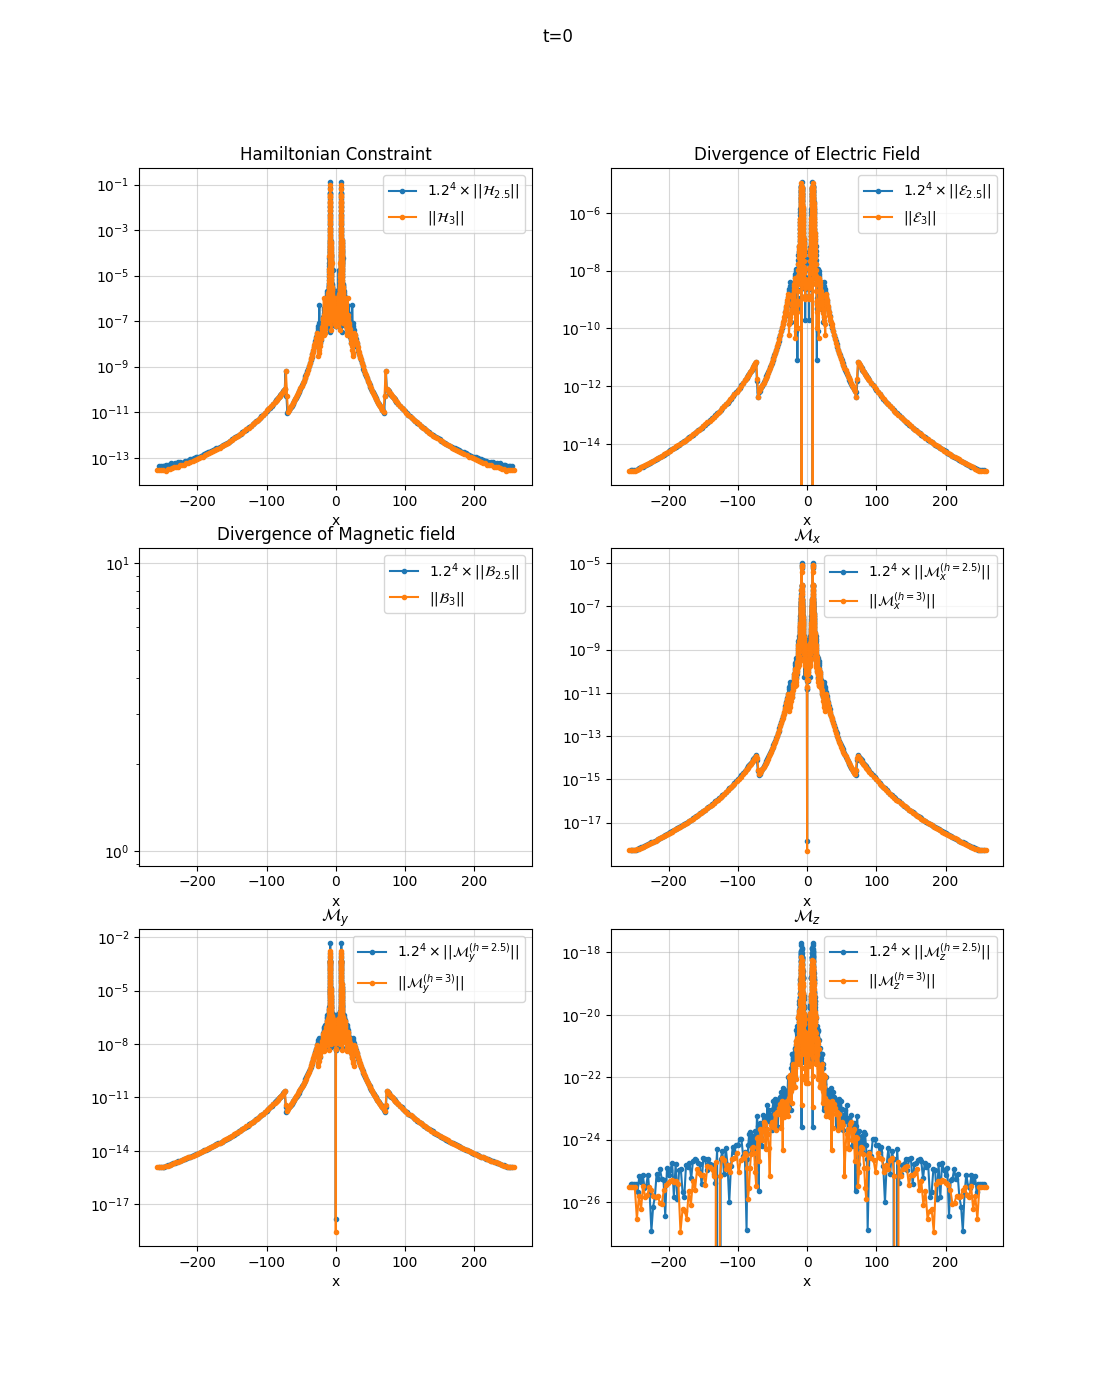

In [16]:
t    = 0  # pick time step here
axis = "x"

fig, ax = plt.subplots(3, 2, figsize=(11.15,14))

fig.suptitle(f"t={t}")


coor_1, data_1 = GetMesh(sd,      "hc", axis)
coor_2, data_2 = GetMesh(sd_res2, "hc", axis)

ax[0,0].plot(coor_1[f"t={t}"], 1.2**4*abs(data_1[f"t={t}"]), marker=".", label=r"$1.2^4 \times ||\mathcal{H}_{2.5}||$")
ax[0,0].plot(coor_2[f"t={t}"],        abs(data_2[f"t={t}"]), marker=".", label=r"$             ||\mathcal{H}_{3}  ||$")

ax[0,0].grid(alpha=0.5)
ax[0,0].set_xlabel(axis)
ax[0,0].set_yscale("log")
ax[0,0].set_title("Hamiltonian Constraint")
ax[0,0].legend()


coor_1, data_1 = GetMesh(sd,      "Ec", axis)
coor_2, data_2 = GetMesh(sd_res2, "Ec", axis)

ax[0,1].plot(coor_1[f"t={t}"], 1.2**4*abs(data_1[f"t={t}"]), marker=".", label=r"$1.2^4 \times ||\mathcal{E}_{2.5}||$")
ax[0,1].plot(coor_2[f"t={t}"],        abs(data_2[f"t={t}"]), marker=".", label=r"$             ||\mathcal{E}_{3}  ||$")

ax[0,1].grid(alpha=0.5)
ax[0,1].set_xlabel(axis)
ax[0,1].set_yscale("log")
ax[0,1].set_title("Divergence of Electric Field")
ax[0,1].legend()


coor_1, data_1 = GetMesh(sd,      "Bc", axis)
coor_2, data_2 = GetMesh(sd_res2, "Bc", axis)

ax[1,0].plot(coor_1[f"t={t}"], 1.2**4*abs(data_1[f"t={t}"]), marker=".", label=r"$1.2^4 \times ||\mathcal{B}_{2.5}||$")
ax[1,0].plot(coor_2[f"t={t}"],        abs(data_2[f"t={t}"]), marker=".", label=r"$             ||\mathcal{B}_{3}  ||$")

ax[1,0].grid(alpha=0.5)
ax[1,0].set_xlabel(axis)
ax[1,0].set_yscale("log")
ax[1,0].set_title("Divergence of Magnetic field")
ax[1,0].legend();


coor_1, data_1 = GetMesh(sd,      "mcx", axis)
coor_2, data_2 = GetMesh(sd_res2, "mcx", axis)

ax[1,1].plot(coor_1[f"t={t}"], 1.2**4*abs(data_1[f"t={t}"]), marker=".", label=r"$1.2^4 \times ||\mathcal{M}_x^{(h=2.5)}||$")
ax[1,1].plot(coor_2[f"t={t}"],        abs(data_2[f"t={t}"]), marker=".", label=r"$             ||\mathcal{M}_x^{(h=3)}  ||$")

ax[1,1].grid(alpha=0.5)
ax[1,1].set_xlabel(axis)
ax[1,1].set_yscale("log")
ax[1,1].set_title(r"$\mathcal{M}_x$")
ax[1,1].legend();

coor_1, data_1 = GetMesh(sd,      "mcy", axis)
coor_2, data_2 = GetMesh(sd_res2, "mcy", axis)

ax[2,0].plot(coor_1[f"t={t}"], 1.2**4*abs(data_1[f"t={t}"]), marker=".", label=r"$1.2^4 \times ||\mathcal{M}_y^{(h=2.5)}||$")
ax[2,0].plot(coor_2[f"t={t}"],        abs(data_2[f"t={t}"]), marker=".", label=r"$             ||\mathcal{M}_y^{(h=3)}  ||$")

ax[2,0].grid(alpha=0.5)
ax[2,0].set_xlabel(axis)
ax[2,0].set_yscale("log")
ax[2,0].set_title(r"$\mathcal{M}_y$")
ax[2,0].legend();

coor_1, data_1 = GetMesh(sd,      "mcz", axis)
coor_2, data_2 = GetMesh(sd_res2, "mcz", axis)

ax[2,1].plot(coor_1[f"t={t}"], 1.2**4*abs(data_1[f"t={t}"]), marker=".", label=r"$1.2^4 \times ||\mathcal{M}_z^{(h=2.5)}||$")
ax[2,1].plot(coor_2[f"t={t}"],        abs(data_2[f"t={t}"]), marker=".", label=r"$             ||\mathcal{M}_z^{(h=3)}  ||$")

ax[2,1].grid(alpha=0.5)
ax[2,1].set_xlabel(axis)
ax[2,1].set_yscale("log")
ax[2,1].set_title(r"$\mathcal{M}_z$")
ax[2,1].legend();

/tmp/ipykernel_658579/703608061.py:29: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax[1,0].set_yscale("log")


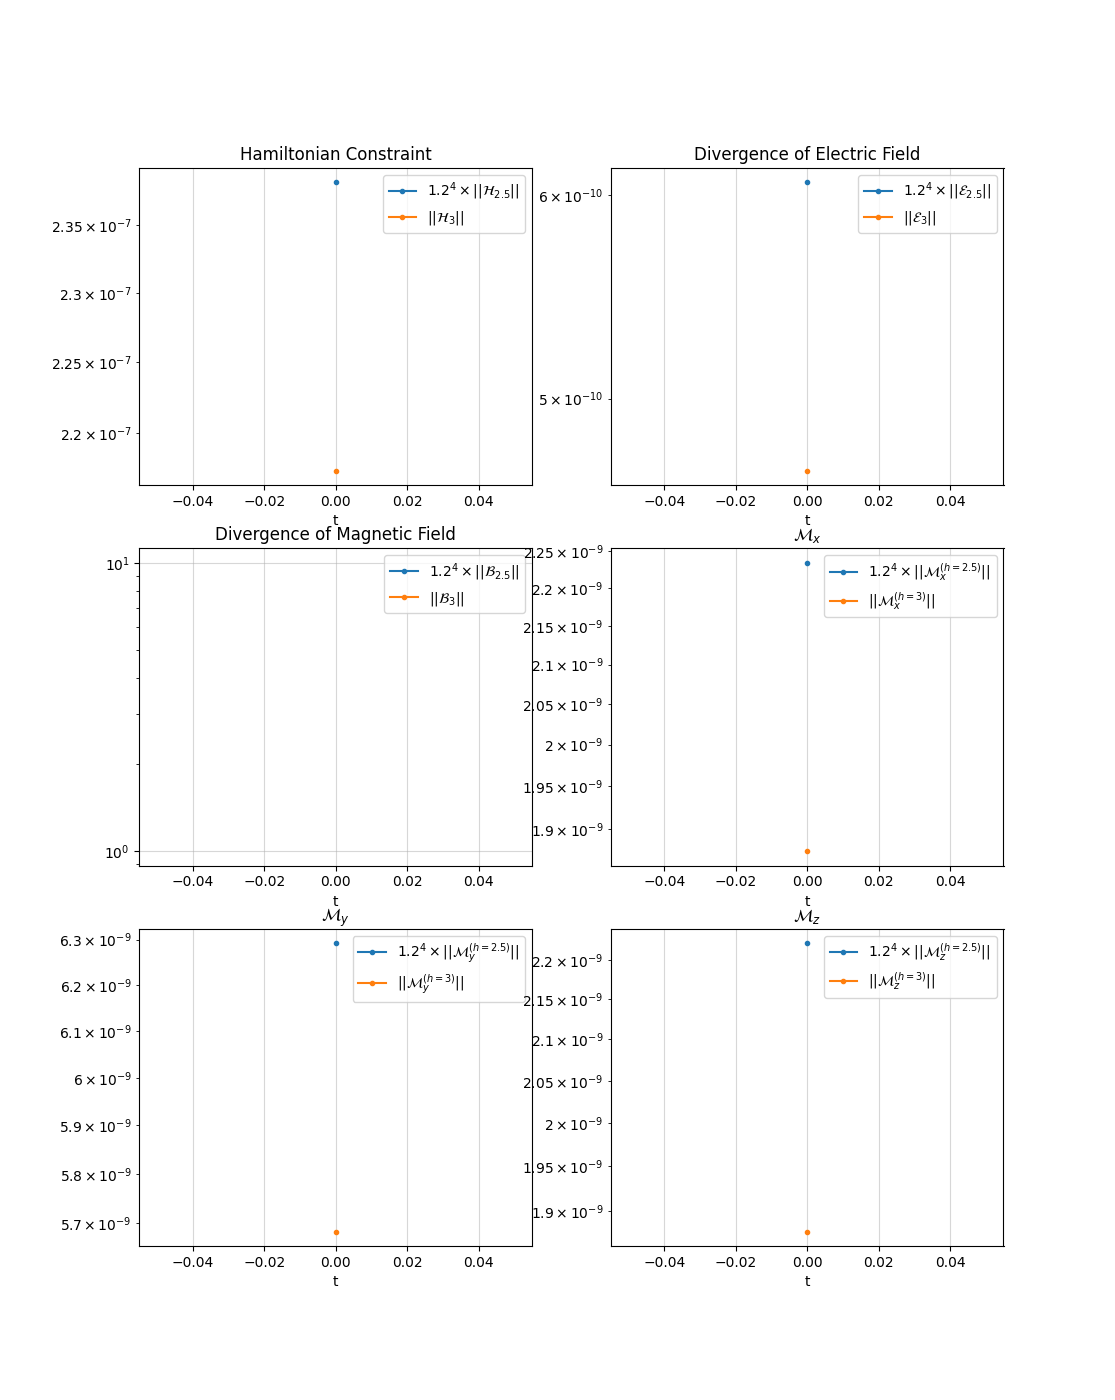

In [17]:
fig, ax = plt.subplots(3, 2, figsize=(11.15,14))


ax[0,0].plot(hc_norm.t,      1.2**4*hc_norm.y,      marker=".", label=r"$1.2^4 \times ||\mathcal{H}_{2.5}||$")
ax[0,0].plot(hc_norm_res2.t,        hc_norm_res2.y, marker=".", label=r"$             ||\mathcal{H}_{3} ||$")

ax[0,0].grid(alpha=0.5)
ax[0,0].set_xlabel("t")
ax[0,0].set_yscale("log")
ax[0,0].set_title("Hamiltonian Constraint")
ax[0,0].legend()


ax[0,1].plot(Ec_norm.t,      1.2**4*Ec_norm.y,      marker=".", label=r"$1.2^4 \times ||\mathcal{E}_{2.5}||$")
ax[0,1].plot(Ec_norm_res2.t,        Ec_norm_res2.y, marker=".", label=r"$             ||\mathcal{E}_{3}  ||$")

ax[0,1].grid(alpha=0.5)
ax[0,1].set_xlabel("t")
ax[0,1].set_yscale("log")
ax[0,1].set_title("Divergence of Electric Field")
ax[0,1].legend()


ax[1,0].plot(Bc_norm.t,      1.2**4*Bc_norm.y,      marker=".", label=r"$1.2^4 \times ||\mathcal{B}_{2.5}||$")
ax[1,0].plot(Bc_norm_res2.t,        Bc_norm_res2.y, marker=".", label=r"$             ||\mathcal{B}_{3}  ||$")

ax[1,0].grid(alpha=0.5)
ax[1,0].set_xlabel("t")
ax[1,0].set_yscale("log")
ax[1,0].set_title("Divergence of Magnetic Field")
ax[1,0].legend();


ax[1,1].plot(mcx_norm.t,      1.2**4*mcx_norm.y,      marker=".", label=r"$1.2^4 \times ||\mathcal{M}_x^{(h=2.5)}||$")
ax[1,1].plot(mcx_norm_res2.t,        mcx_norm_res2.y, marker=".", label=r"$             ||\mathcal{M}_x^{(h=3)}  ||$")

ax[1,1].grid(alpha=0.5)
ax[1,1].set_xlabel("t")
ax[1,1].set_yscale("log")
ax[1,1].set_title(r"$\mathcal{M}_x$")
ax[1,1].legend();


ax[2,0].plot(mcy_norm.t,      1.2**4*mcy_norm.y,      marker=".", label=r"$1.2^4 \times ||\mathcal{M}_y^{(h=2.5)}||$")
ax[2,0].plot(mcy_norm_res2.t,        mcy_norm_res2.y, marker=".", label=r"$             ||\mathcal{M}_y^{(h=3)}  ||$")

ax[2,0].grid(alpha=0.5)
ax[2,0].set_xlabel("t")
ax[2,0].set_yscale("log")
ax[2,0].set_title(r"$\mathcal{M}_y$")
ax[2,0].legend();


ax[2,1].plot(mcz_norm.t,      1.2**4*mcz_norm.y,      marker=".", label=r"$1.2^4 \times ||\mathcal{M}_z^{(h=2.5)}||$")
ax[2,1].plot(mcz_norm_res2.t,        mcz_norm_res2.y, marker=".", label=r"$             ||\mathcal{M}_z^{(h=3)}  ||$")

ax[2,1].grid(alpha=0.5)
ax[2,1].set_xlabel("t")
ax[2,1].set_yscale("log")
ax[2,1].set_title(r"$\mathcal{M}_z$")
ax[2,1].legend();

# Merger (Q vs P)

In [22]:
sd            = SimDir("../simulations/Merger_M=0.5,0.5-T=0.05,0.05-alpha=0,0.5pi-x0=8.001_h=2.5")
ts            = sd.timeseries
gf            = sd.gf
hc_norm       = ts.norm2["hc"]
Ec_norm       = ts.norm2["Ec"]
Bc_norm       = ts.norm2["Bc"]
mcx_norm      = ts.norm2["mcx"]
mcy_norm      = ts.norm2["mcy"]
mcz_norm      = ts.norm2["mcz"]

sd_res2       = SimDir("../simulations/Merger_M=0.5,0.5-T=0.05,0.05-alpha=0,0.5pi-x0=8.001_h=3")
ts_res2       = sd_res2.timeseries
gf_res2       = sd_res2.gf
hc_norm_res2  = ts_res2.norm2["hc"]
Ec_norm_res2  = ts_res2.norm2["Ec"]
Bc_norm_res2  = ts_res2.norm2["Bc"]
mcx_norm_res2 = ts_res2.norm2["mcx"]
mcy_norm_res2 = ts_res2.norm2["mcy"]
mcz_norm_res2 = ts_res2.norm2["mcz"]

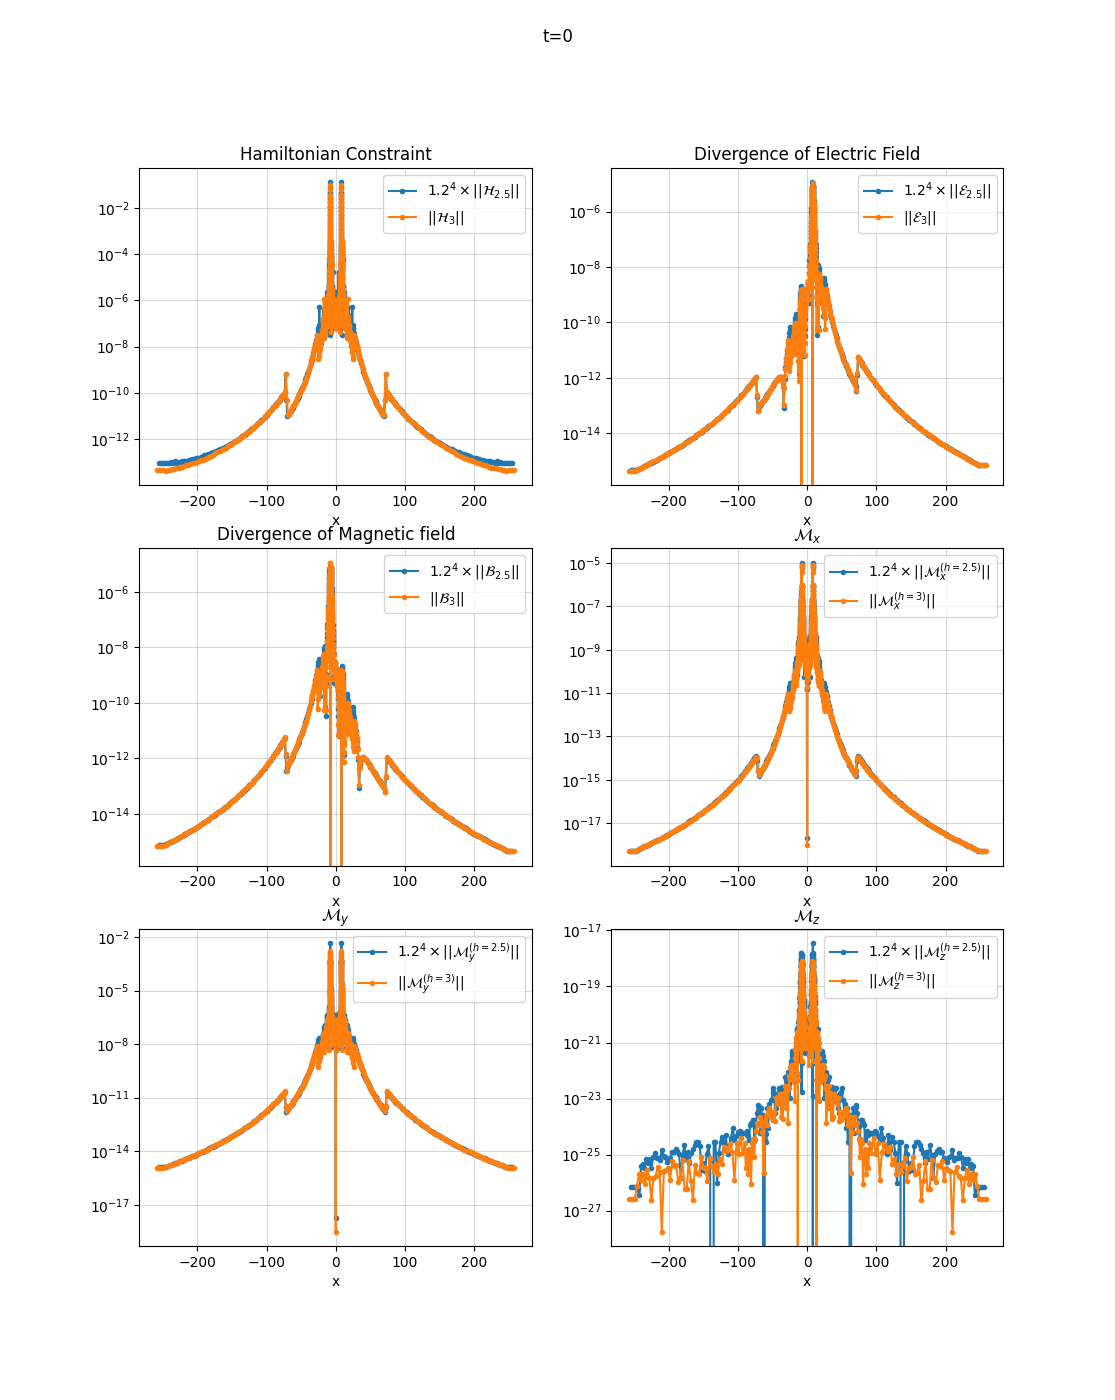

In [25]:
t    = 0  # pick time step here
axis = "x"

fig, ax = plt.subplots(3, 2, figsize=(11.15,14))

fig.suptitle(f"t={t}")


coor_1, data_1 = GetMesh(sd,      "hc", axis)
coor_2, data_2 = GetMesh(sd_res2, "hc", axis)

ax[0,0].plot(coor_1[f"t={t}"], 1.2**4*abs(data_1[f"t={t}"]), marker=".", label=r"$1.2^4 \times ||\mathcal{H}_{2.5}||$")
ax[0,0].plot(coor_2[f"t={t}"],        abs(data_2[f"t={t}"]), marker=".", label=r"$             ||\mathcal{H}_{3}  ||$")

ax[0,0].grid(alpha=0.5)
ax[0,0].set_xlabel(axis)
ax[0,0].set_yscale("log")
ax[0,0].set_title("Hamiltonian Constraint")
ax[0,0].legend()


coor_1, data_1 = GetMesh(sd,      "Ec", axis)
coor_2, data_2 = GetMesh(sd_res2, "Ec", axis)

ax[0,1].plot(coor_1[f"t={t}"], 1.2**4*abs(data_1[f"t={t}"]), marker=".", label=r"$1.2^4 \times ||\mathcal{E}_{2.5}||$")
ax[0,1].plot(coor_2[f"t={t}"],        abs(data_2[f"t={t}"]), marker=".", label=r"$             ||\mathcal{E}_{3}  ||$")

ax[0,1].grid(alpha=0.5)
ax[0,1].set_xlabel(axis)
ax[0,1].set_yscale("log")
ax[0,1].set_title("Divergence of Electric Field")
ax[0,1].legend()


coor_1, data_1 = GetMesh(sd,      "Bc", axis)
coor_2, data_2 = GetMesh(sd_res2, "Bc", axis)

ax[1,0].plot(coor_1[f"t={t}"], 1.2**4*abs(data_1[f"t={t}"]), marker=".", label=r"$1.2^4 \times ||\mathcal{B}_{2.5}||$")
ax[1,0].plot(coor_2[f"t={t}"],        abs(data_2[f"t={t}"]), marker=".", label=r"$             ||\mathcal{B}_{3}  ||$")

ax[1,0].grid(alpha=0.5)
ax[1,0].set_xlabel(axis)
ax[1,0].set_yscale("log")
ax[1,0].set_title("Divergence of Magnetic field")
ax[1,0].legend();


coor_1, data_1 = GetMesh(sd,      "mcx", axis)
coor_2, data_2 = GetMesh(sd_res2, "mcx", axis)

ax[1,1].plot(coor_1[f"t={t}"], 1.2**4*abs(data_1[f"t={t}"]), marker=".", label=r"$1.2^4 \times ||\mathcal{M}_x^{(h=2.5)}||$")
ax[1,1].plot(coor_2[f"t={t}"],        abs(data_2[f"t={t}"]), marker=".", label=r"$             ||\mathcal{M}_x^{(h=3)}  ||$")

ax[1,1].grid(alpha=0.5)
ax[1,1].set_xlabel(axis)
ax[1,1].set_yscale("log")
ax[1,1].set_title(r"$\mathcal{M}_x$")
ax[1,1].legend();

coor_1, data_1 = GetMesh(sd,      "mcy", axis)
coor_2, data_2 = GetMesh(sd_res2, "mcy", axis)

ax[2,0].plot(coor_1[f"t={t}"], 1.2**4*abs(data_1[f"t={t}"]), marker=".", label=r"$1.2^4 \times ||\mathcal{M}_y^{(h=2.5)}||$")
ax[2,0].plot(coor_2[f"t={t}"],        abs(data_2[f"t={t}"]), marker=".", label=r"$             ||\mathcal{M}_y^{(h=3)}  ||$")

ax[2,0].grid(alpha=0.5)
ax[2,0].set_xlabel(axis)
ax[2,0].set_yscale("log")
ax[2,0].set_title(r"$\mathcal{M}_y$")
ax[2,0].legend();

coor_1, data_1 = GetMesh(sd,      "mcz", axis)
coor_2, data_2 = GetMesh(sd_res2, "mcz", axis)

ax[2,1].plot(coor_1[f"t={t}"], 1.2**4*abs(data_1[f"t={t}"]), marker=".", label=r"$1.2^4 \times ||\mathcal{M}_z^{(h=2.5)}||$")
ax[2,1].plot(coor_2[f"t={t}"],        abs(data_2[f"t={t}"]), marker=".", label=r"$             ||\mathcal{M}_z^{(h=3)}  ||$")

ax[2,1].grid(alpha=0.5)
ax[2,1].set_xlabel(axis)
ax[2,1].set_yscale("log")
ax[2,1].set_title(r"$\mathcal{M}_z$")
ax[2,1].legend();

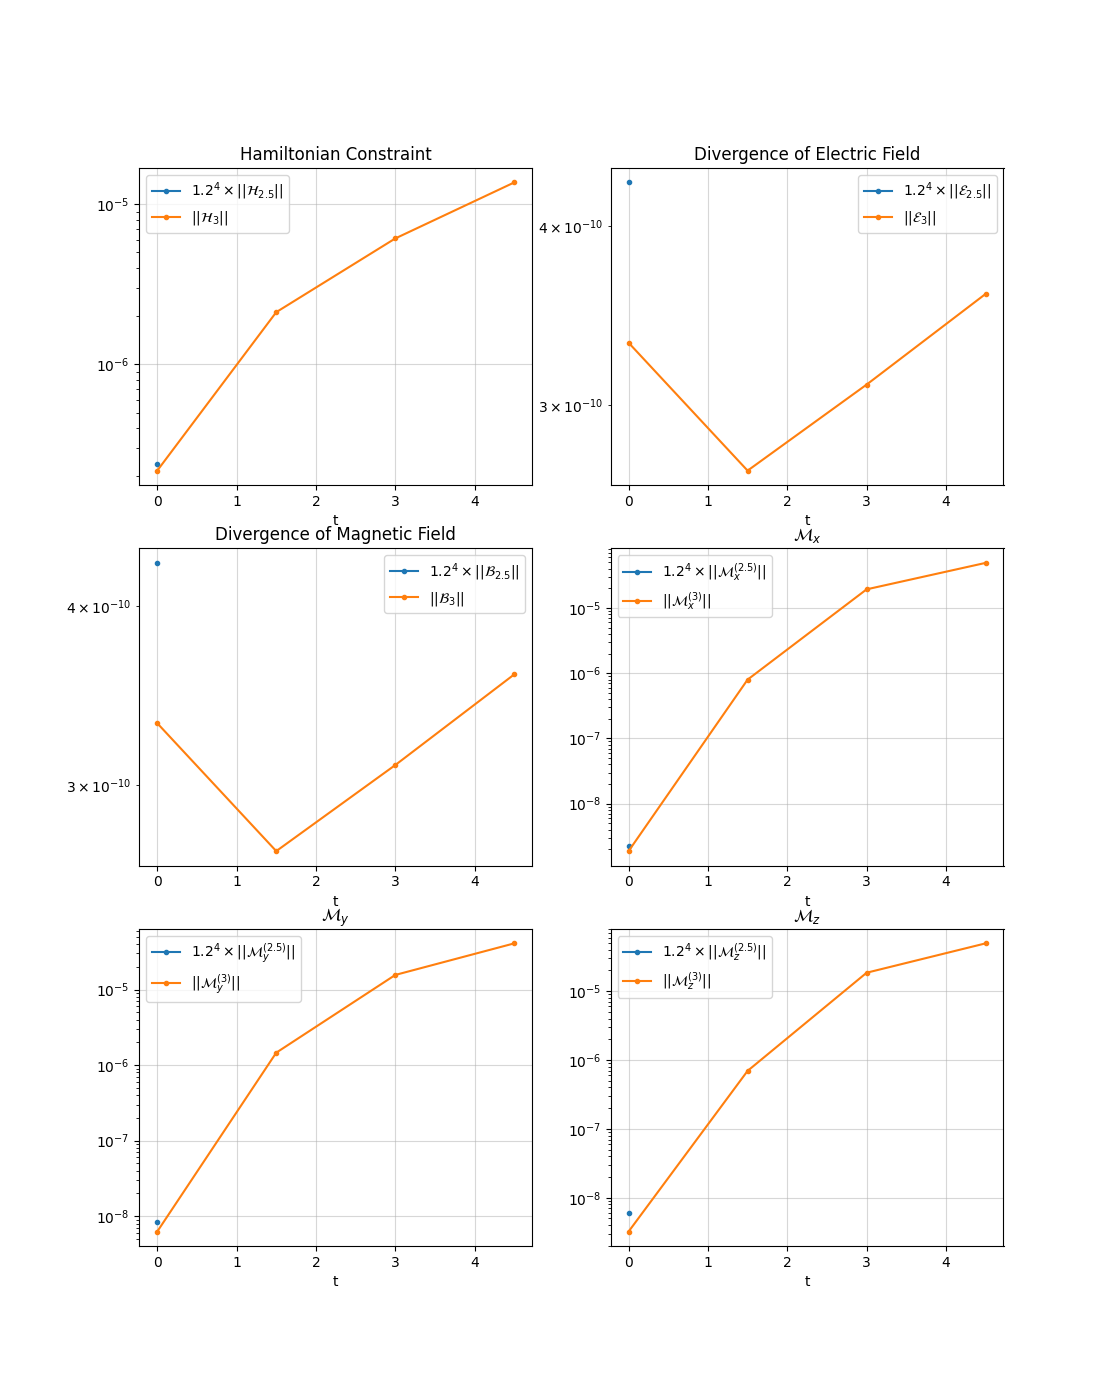

In [26]:
fig, ax = plt.subplots(3, 2, figsize=(11.15,14))


ax[0,0].plot(hc_norm.t,      1.2**4*hc_norm.y,      marker=".", label=r"$1.2^4 \times ||\mathcal{H}_{2.5}||$")
ax[0,0].plot(hc_norm_res2.t,        hc_norm_res2.y, marker=".", label=r"$             ||\mathcal{H}_{3} ||$")

ax[0,0].grid(alpha=0.5)
ax[0,0].set_xlabel("t")
ax[0,0].set_yscale("log")
ax[0,0].set_title("Hamiltonian Constraint")
ax[0,0].legend()


ax[0,1].plot(Ec_norm.t,      1.2**4*Ec_norm.y,      marker=".", label=r"$1.2^4 \times ||\mathcal{E}_{2.5}||$")
ax[0,1].plot(Ec_norm_res2.t,        Ec_norm_res2.y, marker=".", label=r"$             ||\mathcal{E}_{3}  ||$")

ax[0,1].grid(alpha=0.5)
ax[0,1].set_xlabel("t")
ax[0,1].set_yscale("log")
ax[0,1].set_title("Divergence of Electric Field")
ax[0,1].legend()


ax[1,0].plot(Bc_norm.t,      1.2**4*Bc_norm.y,      marker=".", label=r"$1.2^4 \times ||\mathcal{B}_{2.5}||$")
ax[1,0].plot(Bc_norm_res2.t,        Bc_norm_res2.y, marker=".", label=r"$             ||\mathcal{B}_{3}  ||$")

ax[1,0].grid(alpha=0.5)
ax[1,0].set_xlabel("t")
ax[1,0].set_yscale("log")
ax[1,0].set_title("Divergence of Magnetic Field")
ax[1,0].legend();


ax[1,1].plot(mcx_norm.t,      1.2**4*mcx_norm.y,      marker=".", label=r"$1.2^4 \times ||\mathcal{M}_x^{(2.5)}||$")
ax[1,1].plot(mcx_norm_res2.t,        mcx_norm_res2.y, marker=".", label=r"$             ||\mathcal{M}_x^{(3)}  ||$")

ax[1,1].grid(alpha=0.5)
ax[1,1].set_xlabel("t")
ax[1,1].set_yscale("log")
ax[1,1].set_title(r"$\mathcal{M}_x$")
ax[1,1].legend();


ax[2,0].plot(mcy_norm.t,      1.2**4*mcy_norm.y,      marker=".", label=r"$1.2^4 \times ||\mathcal{M}_y^{(2.5)}||$")
ax[2,0].plot(mcy_norm_res2.t,        mcy_norm_res2.y, marker=".", label=r"$             ||\mathcal{M}_y^{(3)}  ||$")

ax[2,0].grid(alpha=0.5)
ax[2,0].set_xlabel("t")
ax[2,0].set_yscale("log")
ax[2,0].set_title(r"$\mathcal{M}_y$")
ax[2,0].legend();


ax[2,1].plot(mcz_norm.t,      1.2**4*mcz_norm.y,      marker=".", label=r"$1.2^4 \times ||\mathcal{M}_z^{(2.5)}||$")
ax[2,1].plot(mcz_norm_res2.t,        mcz_norm_res2.y, marker=".", label=r"$             ||\mathcal{M}_z^{(3)}  ||$")

ax[2,1].grid(alpha=0.5)
ax[2,1].set_xlabel("t")
ax[2,1].set_yscale("log")
ax[2,1].set_title(r"$\mathcal{M}_z$")
ax[2,1].legend();